<a href="https://colab.research.google.com/github/DeVaNsHk72/Computer-Networks/blob/main/youtube_views_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sahideseker/youtube-video-popularity-prediction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'youtube-video-popularity-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/youtube-video-popularity-prediction-dataset


In [ ]:
import numpy as np
import matplotlib.pyplot as pylt
import pandas as pd

In [ ]:
df = pd.read_csv("/14_youtube_video_popularity.csv")
print(df)

    video_id                           title  length  tags_count  \
0    VID0000            Explore Python Other    3467          19   
1    VID0001   Best of Data Science Whatever    2393          10   
2    VID0002  Guide to Data Science American    2332          10   
3    VID0003             Watch Gaming Better    2244          20   
4    VID0004          Best of Review Subject    1665           4   
..       ...                             ...     ...         ...   
995  VID0995     Watch Machine Learning Each    1003          20   
996  VID0996             Best of Gaming Next    3291           5   
997  VID0997           Guide to Startup Huge    2505          18   
998  VID0998        Guide to Vlog Individual    1085           8   
999  VID0999      Learn Data Science Subject    1797          12   

     duration_sec  views  
0            3467   4396  
1            2393   7809  
2            2332   5594  
3            2244  10742  
4            1665   3408  
..            ...    

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
X = df[['length', 'tags_count', 'duration_sec']]
y = df['views']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 2120225.94649047
R2 Score: 0.7654890732423445


In [ ]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
print(coeff_df)

        Feature  Coefficient
0        length     0.634124
1    tags_count   303.805035
2  duration_sec     0.634124


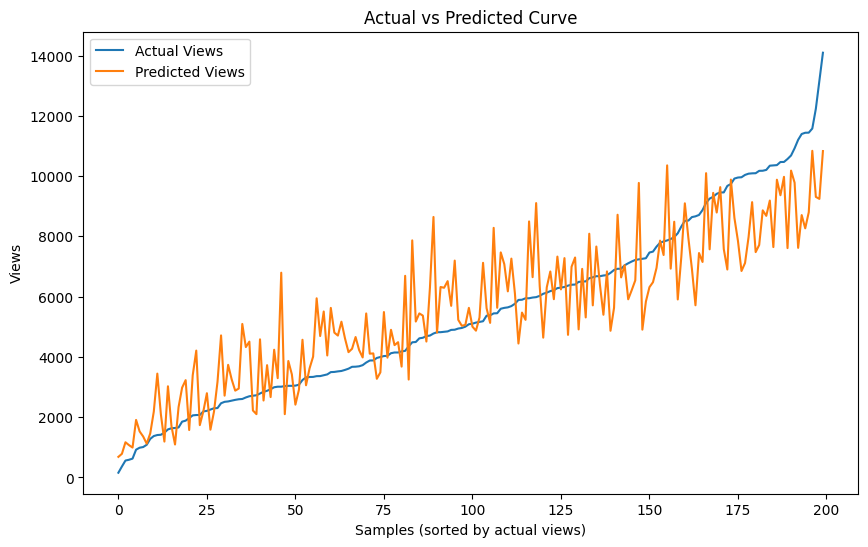

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to numpy arrays
y_test_np = y_test.values
y_pred_np = y_pred

# Sort by actual values (important for smooth curve)
sorted_indices = np.argsort(y_test_np)

y_test_sorted = y_test_np[sorted_indices]
y_pred_sorted = y_pred_np[sorted_indices]

plt.figure(figsize=(10,6))
plt.plot(y_test_sorted, label="Actual Views")
plt.plot(y_pred_sorted, label="Predicted Views")

plt.xlabel("Samples (sorted by actual views)")
plt.ylabel("Views")
plt.title("Actual vs Predicted Curve")
plt.legend()
plt.show()